# Speech Emotion Recognition (SER) Module
Welcome to the SER reference module. In this notebook, we will classify human emotion directly from the voice using acoustic features. Tone, pitch, and energy in the voice carry emotional signals that are independent of the words being said.

### Step 1: Downloading the Dataset & Importing Libraries
We are using the **RAVDESS dataset**, which features 24 professional actors expressing 8 distinct emotions. We will download the audio-only files and import `librosa` for audio processing alongside `sklearn` for our machine learning pipeline.

In [ ]:
# Download the RAVDESS Speech audio-only dataset
!wget -q -O ravdess_data.zip "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"
!unzip -q ravdess_data.zip -d ravdess_data/

import librosa
import soundfile
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

### Step 2: Extracting Acoustic Features
To turn a waveform into numbers a classifier can learn from, we need to extract specific acoustic features. We will create a function that uses `librosa` to extract three key components from each `.wav` file:

*   **MFCC (Mel-Frequency Cepstral Coefficients):** Captures the timbral characteristics of the voice.
*   **Mel Spectrogram:** Captures frequency over time.
*   **Chroma:** Captures pitch-class energy.

In [ ]:
def extract_feature(file_name):
    # 1. Use librosa.load instead of soundfile
    # This automatically converts audio to mono (1D) and resolves the dimension crashes
    X, sample_rate = librosa.load(file_name, sr=None)

    # 2. Extract Features
    # MFCC
    mfccs = np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T, axis=0)

    # Chroma
    stft = np.abs(librosa.stft(X))
    chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)

    # Mel Spectrogram
    mel = np.mean(librosa.feature.melspectrogram(y=X, sr=sample_rate).T, axis=0)

    # Safely combine into a single 1D array
    return np.hstack([mfccs, chroma, mel])

### Step 3: Structuring the Data
The emotion of each RAVDESS file is encoded numerically in its filename. We will map these identifiers to our 8 target emotions (Neutral, Calm, Happy, Sad, Angry, Fearful, Disgust, Surprised). Then, we split the data into training (80%) and testing (20%) sets.

In [ ]:
# Dictionary mapping RAVDESS identifiers to emotion labels
emotions = {
  '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
  '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

In [ ]:
def load_data(test_size=0.2):
    x, y = [], []
    # Loop through all actor folders
    for file in glob.glob("ravdess_data/Actor_*/*.wav"):
        file_name = os.path.basename(file)

        # Skip hidden macOS dotfiles
        if file_name.startswith("._"):
            continue

        try:
            # The emotion identifier is the 3rd element in the filename string
            emotion_code = file_name.split("-")[2]
            emotion = emotions[emotion_code]

            # Extract features and append
            feature = extract_feature(file)
            x.append(feature)
            y.append(emotion)

        except Exception as e:
            print(f"Skipping {file_name} due to an extraction error: {e}")
            continue

    return train_test_split(np.array(x), y, test_size=test_size, random_state=42)

In [ ]:
X_train, X_test, y_train, y_test = load_data(test_size=0.2)
print(f"Dataset is ready! Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Dataset is ready! Training samples: 1152, Testing samples: 288


### Step 4: Multi-Model Training & Evaluation
To ensure robust performance, we will evaluate three different machine learning architectures. We will train a Support Vector Machine (SVM), a Random Forest Classifier, and a Multi-Layer Perceptron (MLP). Comparing these models will highlight which algorithm best separates the emotion classes based on our extracted features.

In [ ]:
# 1. Train and Evaluate Support Vector Machine
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
print(f"SVM Accuracy Score: {accuracy_score(y_test, svm_pred) * 100:.2f}%")

SVM Accuracy Score: 53.12%


In [ ]:
# 2. Train and Evaluate Random Forest
rf_model = RandomForestClassifier(n_estimators=150, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print(f"Random Forest Accuracy Score: {accuracy_score(y_test, rf_pred) * 100:.2f}%")

Random Forest Accuracy Score: 59.38%


In [ ]:
# 3. Train and Evaluate MLP Classifier
mlp_model = MLPClassifier(alpha=0.01, batch_size=256, epsilon=1e-08, hidden_layer_sizes=(300,), learning_rate='adaptive', max_iter=500, random_state=42)
mlp_model.fit(X_train, y_train)
mlp_pred = mlp_model.predict(X_test)
print(f"MLP Accuracy Score: {accuracy_score(y_test, mlp_pred) * 100:.2f}%")

MLP Accuracy Score: 50.69%


In [ ]:
# We will save the best-performing model to a variable for the tester function
# Update this variable based on whichever model scores highest when you run the cell
best_model = rf_model

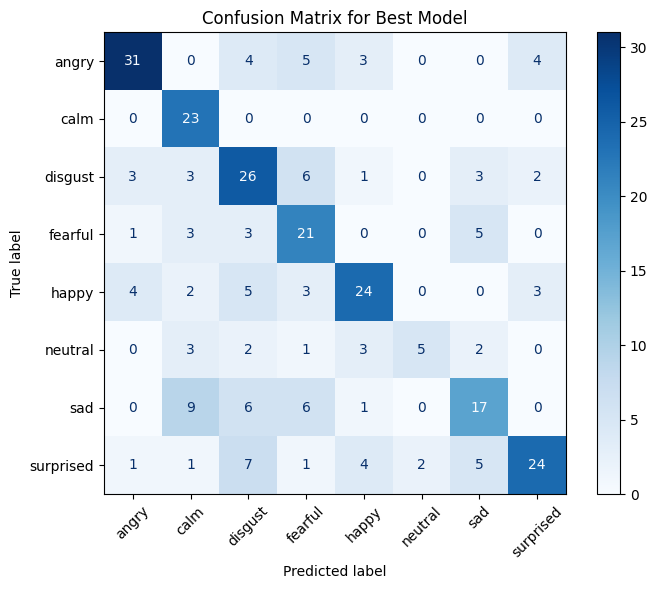

In [ ]:
# Display a confusion matrix for the best model to observe where it gets confused
# (e.g., distinguishing Calm vs Neutral, or Happy vs Surprised)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, best_model.predict(X_test), cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix for Best Model")
plt.show()

### Step 5: The Audio Tester
Similar to our text-based emotion pipeline, this function takes a single audio file, runs it through our feature extraction engine, and uses our best-trained model to guess the emotion.

In [ ]:
# step 5: tester
def test_audio(audio_file_path):
    # Extract features from the new audio file
    features = extract_feature(audio_file_path)

    # Reshape features for a single sample prediction (1 sample, n features)
    features = features.reshape(1, -1)

    # Predict using the model that performed best in Step 4
    prediction = best_model.predict(features)

    print("Audio File:", audio_file_path)
    print("Guessed Emotion:", prediction[0].upper())

In [ ]:
# Let's test it on a random file from our downloaded dataset
sample_test_file = glob.glob("ravdess_data/Actor_01/*.wav")[0]
test_audio(sample_test_file)

Audio File: ravdess_data/Actor_01/03-01-03-01-01-02-01.wav
Guessed Emotion: HAPPY


In [ ]:
import os

# Get the base filename from the sample_test_file path
file_name = os.path.basename(sample_test_file)

# Split the filename by '-' and get the emotion code (3rd element, index 2)
emotion_code = file_name.split('-')[2]

# Look up the emotion in the 'emotions' dictionary
true_emotion = emotions[emotion_code]

print(f"The sample test file name is: {file_name}")
print(f"The emotion code extracted from the filename is: {emotion_code}")
print(f"The true emotion for this file is: {true_emotion.upper()}")

The sample test file name is: 03-01-03-01-01-02-01.wav
The emotion code extracted from the filename is: 03
The true emotion for this file is: HAPPY
